# **Abstract**
- In this semester, I focused on discovering and analyzing the change in Massachusette's vehicle market after the repair law had been introduced in 2013. To zoom into the potential impact brought by the repair law, I conducted empirical analysis on seven major sections of the market: ownership, new car purchase, used car sold, used car purchase, all car purchase, vehicle disposal, and used car trade-in.
- By comparing the performance of Massachusette and other states in the US, I discovered divergences between Massachusette's vehicle market and other states' vehicle markets, including the decline of vehicle ownership in MA after 2014 and the decline of purchase instances in MA after 2014. To statistically confirm the divergence, I conducted difference-in-difference analysis to check if the findings are significant.
- The data sources were FMLI (demographical data), OVB (owned vehicle data), OVC (vehicle disposal data). In the emphirical data analysis section, the time range of the data is from 2008 to 2021. Yet, in the DID analysis section, the time range of the training data is from 2010 to 2019, in order to rule out the impact brought by two major economic crisis (2008 and 2020).

# **Importing Data**
**Data Structure**

- data[yr] = frames
- frames.keys() = ['FMLI', 'OVB', 'OVC']
- frames['FMLI'] = quarterly_fmli
- quarterly_fmli[Quarter] = fmli_yr+quarter

**Time Range**
- from 2008 to 2021

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import os

In [ ]:
data = {}
quarter = ['1x', '2', '3', '4']
state_mapping = pd.read_csv('/content/drive/MyDrive/ucb/URAP_Prof Yang/Mapping/State_Mapping.csv',
                            dtype={'Code value': 'str', 'Code description': 'str'})

for file_name in os.listdir('/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data'):
    if 'intrvw' in file_name:
        yr = file_name[-2:]
        ovb = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw{yr}/expn{yr}/ovb{yr}.csv',
                          dtype={'QYEAR': 'str', 'NEWID': 'str'})
        ovc = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw{yr}/expn{yr}/ovc{yr}.csv',
                          dtype={'QYEAR': 'str', 'NEWID': 'str'})
        quarterly_fmli = {}
        for q in quarter:
            if (yr == '21') & (q == '1x'):
              quarterly_fmli[q] = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw20/intrvw20/fmli211.csv',
                          dtype={'QYEAR': 'str', 'NEWID': 'str', 'STATE': 'str'})
            elif (yr == '20') & (q == '1x'):
              quarterly_fmli[q] = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw19/intrvw19/fmli201.csv',
                          dtype={'QYEAR': 'str', 'NEWID': 'str', 'STATE': 'str'})
            else:
              quarterly_fmli[q] = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw{yr}/intrvw{yr}/fmli{yr}{q}.csv',
                          dtype={'QYEAR': 'str', 'NEWID': 'str', 'STATE': 'str'})
            quarterly_fmli[q] = quarterly_fmli[q].merge(state_mapping, how = 'left', left_on = 'STATE', right_on = 'Code value').drop(columns=['Code value', 'STATE']).rename(columns = {'Code description': 'State'})

        frames = {'OVB': ovb,
                  'OVC': ovc}

        for df in list(frames.values()) + list(quarterly_fmli.values()):
            # extracting household and interview id
            df['Household'], df['Interview'] = df['NEWID'].apply(lambda x: (x[:-1])), df['NEWID'].apply(lambda x: (x[-1]))
            df.drop(columns='NEWID', inplace=True)

            # extracting year and quarter information
            if 'QYEAR' in df.columns:
                df['Year'], df['Quarter'] = df['QYEAR'].apply(lambda x: x[:-1]), df['QYEAR'].apply(lambda x: x[-1])
                df.drop(columns='QYEAR', inplace=True)

        frames['FMLI'] = quarterly_fmli

        data[yr] = frames

<ipython-input-4-368fdfef32ab>:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  ovb = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw{yr}/expn{yr}/ovb{yr}.csv',
<ipython-input-4-368fdfef32ab>:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  ovb = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw{yr}/expn{yr}/ovb{yr}.csv',
<ipython-input-4-368fdfef32ab>:22: DtypeWarning: Columns (803) have mixed types. Specify dtype option on import or set low_memory=False.
  quarterly_fmli[q] = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw{yr}/intrvw{yr}/fmli{yr}{q}.csv',
<ipython-input-4-368fdfef32ab>:22: DtypeWarning: Columns (17,19,55,109) have mixed types. Specify dtype option on import or set low_memory=False.
  quarterly_fmli[q] = pd.read_csv(f'/content/drive/MyDrive/ucb/URAP_Prof Yang/Raw Data/intrvw{yr}/intrvw{yr}

# **Product Market Empirical Analysis**

## **Data Processing**

### Get Detail Function
- get_detail(state_name/'all')
- details = {'Damage', 'Sold', 'Tradein', 'Giveaway', 'Stolen', 'Bought_used', 'Bought_new'}

May use the function to get the conditonal dataframes of a specific location.

In [ ]:
def get_detail(state_name):
    details = {}

    for yr in sorted(data.keys()):

        household = pd.Series()
        ownership = pd.DataFrame()
        for qr in data[yr]['FMLI'].keys():
            temp = data[yr]['FMLI'][qr]
          # get the household from a specific state
            if state_name == "all":
                household = pd.concat([household, temp.loc[(temp['State'] != 'Massachusetts') & (pd.notnull(temp['State'])), 'Household']])
            else:
                household = pd.concat([household, temp.loc[temp['State'] == state_name, 'Household']])

            # ownership record
            # use variable VEHQ in FMLI
            ownership_qr = temp.loc[:, ['Household', 'VEHQ']]
            ownership_qr['Quarter'] = qr
            ownership_qr['Year'] = '20' + yr
            ownership = pd.concat([ownership, ownership_qr], axis = 0)

        household = household.drop_duplicates()
        ownership = ownership.loc[ownership['Household'].isin(household)]

        ovb = data[yr]['OVB']
        ovc = data[yr]['OVC']

        # VEHDISP = disposal method: demaged beyond repair (4)
        # VEHICYC = Vehicle item code (type of vehicle)
        # classifying the records into different types of disposal
        damage_disp = ovc[(ovc['VEHDISP'].isin([4])) & (ovc['VEHICYC'] <= 110) & (ovc['Household'].isin(household))]
        sold_disp = ovc[(ovc['VEHDISP'].isin([1])) & (ovc['VEHICYC'] <= 110) & (ovc['Household'].isin(household))]
        tradein_disp = ovc[(ovc['VEHDISP'].isin([2])) & (ovc['VEHICYC'] <= 110) & (ovc['Household'].isin(household))]
        giveaway_disp = ovc[(ovc['VEHDISP'].isin([3])) & (ovc['VEHICYC'] <= 110) & (ovc['Household'].isin(household))]
        stolen_disp = ovc[(ovc['VEHDISP'].isin([5])) & (ovc['VEHICYC'] <= 110) & (ovc['Household'].isin(household))]
        other_disp = ovc[(ovc['VEHDISP'].isin([6])) & (ovc['VEHICYC'] <= 110) & (ovc['Household'].isin(household))]

        # VEHNEWU = new or used when acquired?: new (1), used (2)
        # recent used car purchase record, no duplicate
        bought_used = ovb[(ovb['VEHNEWU'] == 2) & (ovb['VEHPURYR'] == (2000 + int(yr))) & (ovb['VEHICYB'] <= 110) & (ovb['Household'].isin(household))].fillna(-1)
        bought_used = bought_used.replace(to_replace = {'.': -1})
        bought_used['NETPURX'] = bought_used['NETPURX'].astype('int')
        cleaned_bought_used = bought_used.groupby(['Household', 'MAKE', 'VEHPURMO', 'VEHPURYR'], as_index=False)['NETPURX'].mean()
        # recent new car purchase record, no duplicate
        bought_new = ovb[(ovb['VEHNEWU'] == 1) & (ovb['VEHPURYR'] == (2000 + int(yr))) & (ovb['VEHICYB'] <= 110) & (ovb['Household'].isin(household))].fillna(-1)
        bought_new = bought_new.replace(to_replace = {'.': -1})
        bought_new['NETPURX'] = bought_new['NETPURX'].astype('int')
        cleaned_bought_new = bought_new.groupby(['Household', 'MAKE', 'VEHPURMO', 'VEHPURYR'], as_index=False)['NETPURX'].mean()

        bought = ovb[(ovb['VEHPURYR'] == (2000 + int(yr))) & (ovb['VEHICYB'] <= 110) & (ovb['Household'].isin(household))].fillna(-1)
        bought = bought.replace(to_replace = {'.': -1})
        bought['NETPURX'] = bought['NETPURX'].astype('int')
        bought['TRADEX'] = bought['TRADEX'].astype('int')
        cleaned_bought = bought.groupby(['Household', 'MAKE', 'VEHPURMO', 'VEHPURYR'])[['NETPURX', 'TRADEX']].mean().reset_index()


        details[yr] = {'Damage': damage_disp,
                       'Sold': sold_disp,
                       'Tradein': tradein_disp,
                       'Giveaway': giveaway_disp,
                       'Stolen': stolen_disp,
                       'Other': other_disp,
                       'Bought_used': cleaned_bought_used,
                       'Bought_new': cleaned_bought_new,
                       'Bought': cleaned_bought,
                       'Ownership': ownership,
                       'Household_code': household
                      }

    return details

### Running the function

In [ ]:
details_MA = get_detail('Massachusetts')
details_all = get_detail('all')

## **1. Ownership**

The initial assumption on the change of vehicle ownership in MA is that the ownership will decline after the introduction of the policy. Since repairing would be easier, there is no need to have backup cars for a household.

**Data Source:** FMLI
- There is a attribute (VEHQ) in FMLI recording the number of vehicle owned by a household.

**Findings:**
1. Mean and median amount of car ownership dropped after 2014 in MA.
2. The Proportion of household owning at least 1 car dropped after 2015 in MA
3. The proportion of household owning at least 3 cars dropped after 2014 in MA.

According to the graphs below, the number of vehicle owned by each household dropped significantly after 2014, which is potentially correlated with the introduction of the repair law.

### Get Ownership Function
- get_own(details)
- return a dataframe containing the year, the quarter, the average number of vehicles owned by a household, the median number of vehicles owned by a household, the porportion of household owning at least 1 car, and the porportion of household owning at least 3 cars

In [ ]:
def get_own(details):

    ownership = pd.DataFrame();
    at_least_1 = pd.Series();
    at_least_3 = pd.Series();

    for yr in details.keys():
      # need to add an ownership section in the details dictionary
        df = details[yr]['Ownership'].copy()
        df['VEHQ'] = df['VEHQ'].astype('int')

        at_least_1_yr = np.sum(df['VEHQ'] >= 1) / df.shape[0]
        at_least_1 = pd.concat([at_least_1, pd.Series([at_least_1_yr])])

        at_least_3_yr = np.sum(df['VEHQ'] >= 3) / df.shape[0]
        at_least_3 = pd.concat([at_least_3, pd.Series([at_least_3_yr])])

        ownership_yr = df.groupby('Year', as_index = False).agg({'VEHQ': [('Mean Vehicle Ownership', 'mean'), ('Median Vehicle Ownership', 'median')]})
        ownership = pd.concat([ownership, ownership_yr], axis = 0)

    ownership['% Household Owned at Least One Car'] = at_least_1 * 100
    ownership['% Household Owned at Least Three Cars'] = at_least_3 * 100

    return ownership

### Runing the Function

In [ ]:
ownership_MA = get_own(details_MA)
ownership_all = get_own(details_all)

In [ ]:
ownership_MA.head()

Year                   VEHQ                           \
        Mean Vehicle Ownership Median Vehicle Ownership   
0  2008               1.430528                      1.0   
0  2009               1.574653                      1.0   
0  2010               1.570384                      1.0   
0  2011               1.627240                      2.0   
0  2012               1.500917                      1.0   

  % Household Owned at Least One Car % Household Owned at Least Three Cars  
                                                                            
0                          84.344423                             13.502935  
0                          85.416667                             14.236111  
0                          85.009141                             15.173675  
0                          83.154122                             16.308244  
0                          81.467890                             12.477064

### **Vehicle Ownership**

Text(0, 0.5, 'Mean Number of Vehicle Owned by a Household')

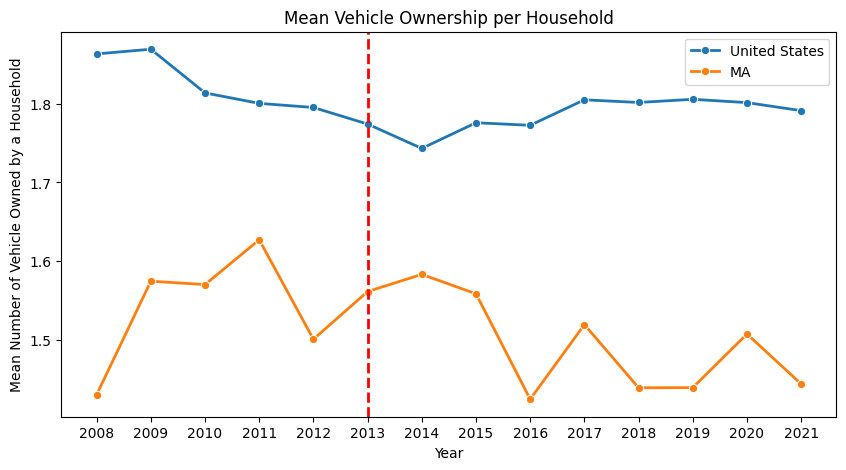

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(data = ownership_all, x = 'Year', y = ('VEHQ', 'Mean Vehicle Ownership'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = ownership_MA, x = 'Year', y = ('VEHQ', 'Mean Vehicle Ownership'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Mean Vehicle Ownership per Household')
plt.xlabel('Year')
plt.ylabel('Mean Number of Vehicle Owned by a Household')

Text(0, 0.5, 'Median Number of Vehicle Owned by a Household')

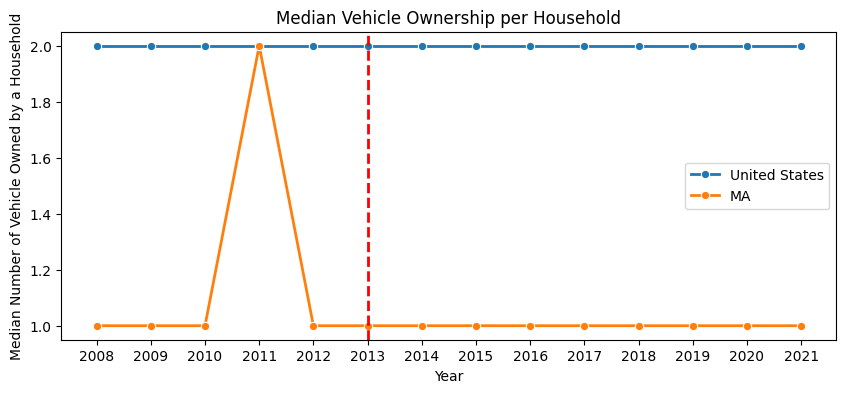

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(data = ownership_all, x = 'Year', y = ('VEHQ', 'Median Vehicle Ownership'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = ownership_MA, x = 'Year', y = ('VEHQ', 'Median Vehicle Ownership'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Median Vehicle Ownership per Household')
plt.xlabel('Year')
plt.ylabel('Median Number of Vehicle Owned by a Household')

Text(0, 0.5, '% Household Owned at Least One Car')

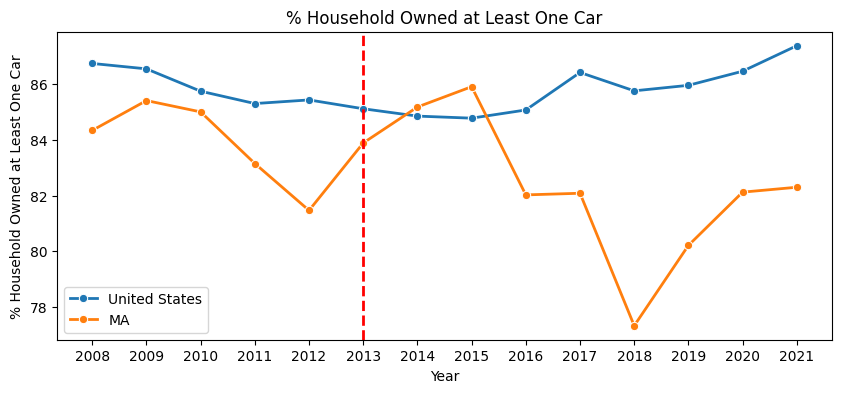

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(data = ownership_all, x = 'Year', y = '% Household Owned at Least One Car', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = ownership_MA, x = 'Year', y = '% Household Owned at Least One Car', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('% Household Owned at Least One Car')
plt.xlabel('Year')
plt.ylabel('% Household Owned at Least One Car')

Text(0, 0.5, '% Household Owned at Least Three Cars')

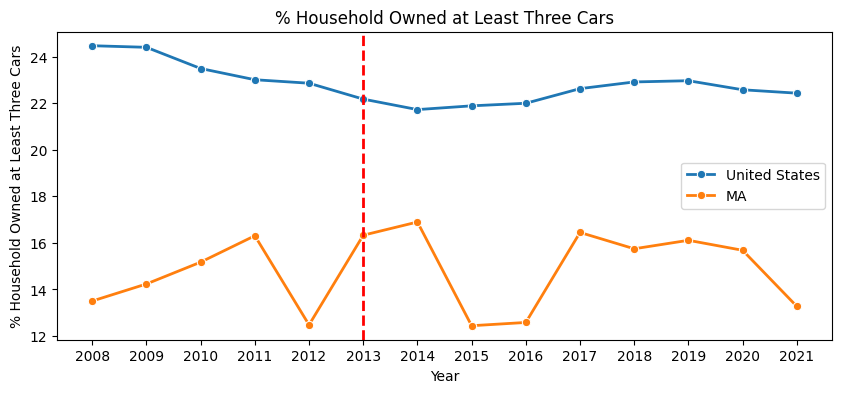

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(data = ownership_all, x = 'Year', y = '% Household Owned at Least Three Cars', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = ownership_MA, x = 'Year', y = '% Household Owned at Least Three Cars', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('% Household Owned at Least Three Cars')
plt.xlabel('Year')
plt.ylabel('% Household Owned at Least Three Cars')

## **2. New Car Purchase**

To maximize profit, the producers might increase the new car purchase price to offset the loss of possible decrease in demand.

**Data Source:** OVB
- I used a filter to select owned vehicle which has the same purchase year as the year of survey and marked as new to get the new car purchase records.

**Findings:**
1. Median and mean new car purchase prices in MA increases after 2013, while they don't divert significantly from the trend of other states in the US.
3. The new car purchase price for the whole country also gradually increases over the year. (may due to inflation)

However, the graphs show that the difference between the new car purchase price in MA and in other states is not significant. They both increase after 2013, so we can't conclude that there's a correlation between the repair law and the new car purchase price.

### Get Purchase Function

- get_purchase_new(details)
- return a dataframe with year, quarter, the amount of new car purchase in each time period, the mean purchase price, and the median purchase price.

In [ ]:
def get_purchase_new(details):
  # VEHPURMO purchase month
  purchase = pd.DataFrame();
  null_proportion = pd.Series();
  household_w_null = pd.Series();
  prop_purchase = pd.Series();

  for yr in details.keys():
      raw = details[yr]['Bought_new'].copy()
      df = raw.loc[raw['NETPURX'] != -1]

      #get purchase price
      df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
      purchase_yr = df.groupby('Year').agg({'NETPURX': [('Mean Bought Price', 'mean'), ('Median Bought Price', 'median')], 'Household': [('Count', 'nunique')]}).reset_index()

      #get sample size (null purchase vs all purchase)
      null_proportion = pd.concat([null_proportion, pd.Series([raw.loc[raw['NETPURX'] == -1].shape[0] / raw.shape[0]])])

      #amount of household with null
      household_w_null = pd.concat([household_w_null, pd.Series([raw['Household'].nunique()])])

      #num of purchase / num of household
      num_household = details[yr]['Household_code'].shape[0]
      prop_purchase = pd.concat([prop_purchase, pd.Series([raw.shape[0] / num_household])])

      purchase = pd.concat([purchase, purchase_yr], axis = 0)

  purchase['Household (with null)'] = household_w_null
  purchase['Null Rate'] = null_proportion
  purchase['Purchase Rate'] = prop_purchase

  return purchase

### Run the Function

In [ ]:
purchase_new_MA = get_purchase_new(details_MA)
purchase_new_all = get_purchase_new(details_all)

<ipython-input-14-f966bc733d53>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-14-f966bc733d53>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-14-f966bc733d53>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'M

In [ ]:
purchase_new_MA

Year           NETPURX                     Household  \
          Mean Bought Price Median Bought Price     Count   
0  2008.0      19830.000000             20000.0         5   
0  2009.0      23534.428571             22000.0        14   
0  2010.0      23931.676471             24894.0        15   
0  2011.0      29019.111111             27500.0         9   
0  2012.0      31250.666667             34000.0         7   
0  2013.0      24630.400000             22000.0        14   
0  2014.0      23105.555556             24000.0         9   
0  2015.0      29894.909091             29000.0        11   
0  2016.0      23273.272727             21250.0        10   
0  2017.0      23831.333333             24000.0         6   
0  2018.0      28128.642857             25850.0        13   
0  2019.0      36550.000000             38250.0         9   
0  2020.0      32145.555556             27060.0         9   
0  2021.0      16450.000000             17000.0         6   

  Household (with null) Null Rate Purchase Rate  
                                                 
0                     8  0.375000      0.030303  
0                    16  0.125000      0.057554  
0                    16  0.055556      0.063380  
0                     9  0.100000      0.034843  
0                     8  0.181818      0.039568  
0                    14  0.000000      0.061475  
0                    10  0.100000      0.043290  
0                    13  0.153846      0.052632  
0                    10  0.000000      0.032738  
0                     7  0.142857      0.021148  
0                    14  0.066667      0.046875  
0                    10  0.166667      0.038835  
0                    10  0.100000      0.032787  
0                     8  0.250000      0.026144

In [ ]:
purchase_new_all

Year           NETPURX                     Household  \
          Mean Bought Price Median Bought Price     Count   
0  2008.0      24418.452160             22522.5       306   
0  2009.0      23671.299738             21500.0       364   
0  2010.0      25479.144509             24000.0       327   
0  2011.0      27005.835260             25214.0       323   
0  2012.0      26306.973621             25000.0       394   
0  2013.0      26335.846467             25939.0       351   
0  2014.0      29085.650450             27000.0       350   
0  2015.0      28818.185012             27296.0       408   
0  2016.0      29186.269521             27025.0       383   
0  2017.0      31321.066929             28871.0       360   
0  2018.0      31377.419619             28560.0       351   
0  2019.0      31852.921474             30000.0       298   
0  2020.0      34879.511986             32000.0       273   
0  2021.0      39735.161150             36000.0       275   

  Household (with null) Null Rate Purchase Rate  
                                                 
0                   472  0.358416      0.043640  
0                   438  0.173160      0.039406  
0                   380  0.149877      0.033869  
0                   385  0.176190      0.036304  
0                   469  0.175889      0.043969  
0                   410  0.159817      0.039198  
0                   421  0.172260      0.039663  
0                   471  0.149402      0.045201  
0                   434  0.131291      0.039288  
0                   436  0.199580      0.042165  
0                   416  0.165909      0.041529  
0                   373  0.208122      0.039274  
0                   339  0.204360      0.036829  
0                   340  0.204986      0.035956

### **New Car Purchase Price**

Text(0, 0.5, 'Purchase Price ($)')

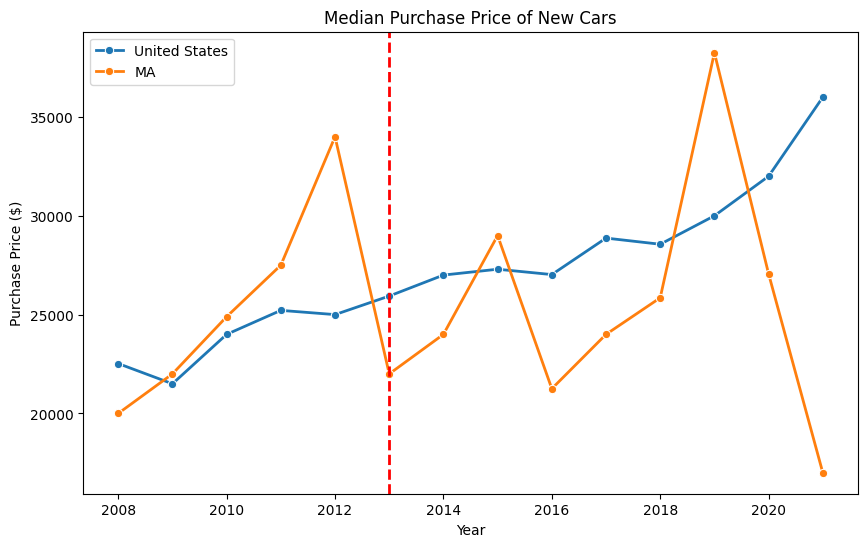

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_new_all, x = 'Year', y = ('NETPURX', 'Median Bought Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_new_MA, x = 'Year', y = ('NETPURX', 'Median Bought Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Median Purchase Price of New Cars')
plt.xlabel('Year')
plt.ylabel('Purchase Price ($)')

Text(0, 0.5, 'Purchase Price ($)')

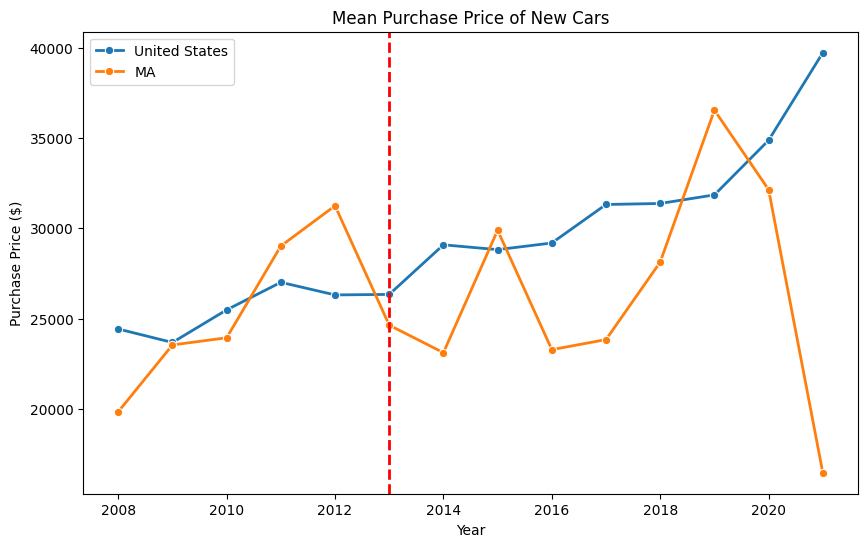

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_new_all, x = 'Year', y = ('NETPURX', 'Mean Bought Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_new_MA, x = 'Year', y = ('NETPURX', 'Mean Bought Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Mean Purchase Price of New Cars')
plt.xlabel('Year')
plt.ylabel('Purchase Price ($)')

- check Tim and Ashley

### **Discovering the Sample**
- Since there are nulls in the purchase price data, I created a graph to monitor the proportion of nulls in the sample.

(0.0, 0.3)

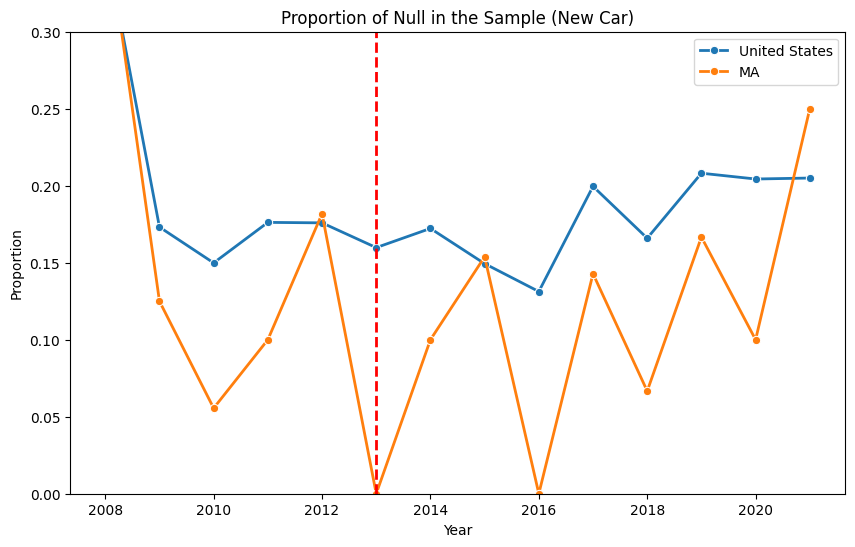

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_new_all, x = 'Year', y = 'Null Rate', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_new_MA, x = 'Year', y = 'Null Rate', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Proportion of Null in the Sample (New Car)')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim((0, 0.3))

(0.0, 0.1)

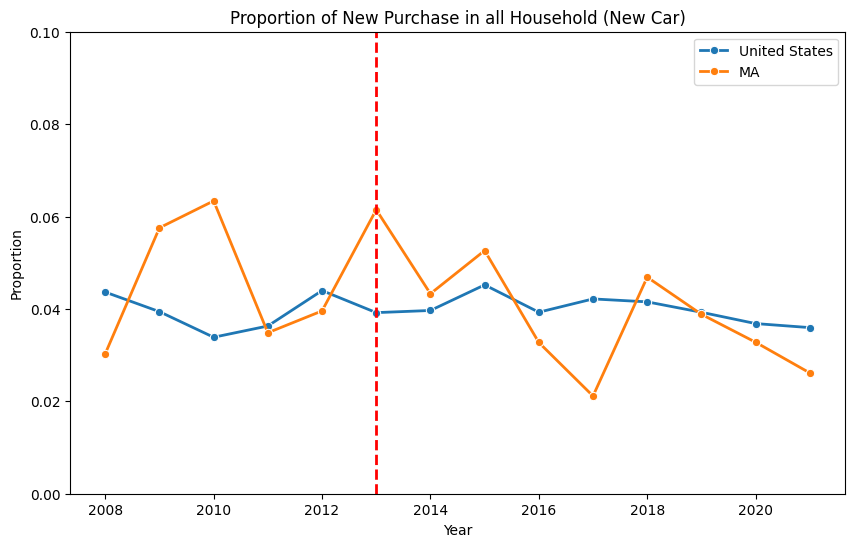

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_new_all, x = 'Year', y = 'Purchase Rate', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_new_MA, x = 'Year', y = 'Purchase Rate', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Proportion of New Purchase in all Household (New Car)')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim((0, 0.1))

## **3. Used Car Sold**

Persumably, the used car sold price will increase as households would have more accessibility to repairment and used car would have better condition.

**Data Source:** OVC
- Only record marked as disposal method equals to "sold" has a sold price. Thus, I selected all records disposed by "sold" to get the used car sold price.

However, the sample size of used cars sold by their owners is too small to analyze the trend that a single outlier will significantly affect the mean. Moreover, the used car sold price fluctuates accross the years, which doesn't seem to have a trend after the repair law.

### Get Price Function
- get_price_qr(details)
- return a dataframe containing the year, the quarter, the average sold price, and the median sold price of used cars at that year.

In [ ]:
def get_price_qr(details):

    sold_price = pd.DataFrame();

    for yr in details.keys():
        df = details[yr]['Sold'].copy()
        df = df.replace(to_replace = {'.': -1})
        sold_price_yr = df.loc[(df['SALEX'] != '-1') & (df['Year'] == f'20{yr}') & (df['Quarter'] != '5'), ['Year', 'Quarter', 'SALEX', 'Household']].dropna()
        sold_price_yr['SALEX'] = sold_price_yr['SALEX'].astype('int')
        sold_price_yr = sold_price_yr.groupby(['Year', 'Quarter']).agg({'SALEX': [('Mean Sold Price', 'mean'), ('Median Sold Price', 'median')], 'Household': [('Count', 'count')]})
        sold_price = pd.concat([sold_price, sold_price_yr], axis = 0)

    sold_price = sold_price.reset_index()
    sold_price['QYEAR'] = sold_price['Year'] + sold_price['Quarter']

    return sold_price

- get_price_yr(details)
- return a dataframe containing the year, the average sold price, and the median sold price of used cars at that year.

In [ ]:
def get_price_yr(details):

    sold_price = pd.DataFrame();

    for yr in details.keys():
        df = details[yr]['Sold'].copy()
        df = df.replace(to_replace = {'.': -1})
        sold_price_yr = df.loc[(df['SALEX'] != '-1') & (df['Year'] == f'20{yr}') & (df['Quarter'] != '5'), ['Year', 'Quarter', 'SALEX', 'Household']].dropna()
        sold_price_yr['SALEX'] = sold_price_yr['SALEX'].astype('int')
        sold_price_yr = sold_price_yr.groupby('Year').agg({'SALEX': [('Mean Sold Price', 'mean'), ('Median Sold Price', 'median')], 'Household': [('Count', 'count')]})
        sold_price = pd.concat([sold_price, sold_price_yr], axis = 0)

    sold_price = sold_price.reset_index()

    return sold_price

### Running the Function

In [ ]:
sold_price_MA = get_price_qr(details_MA)
sold_price_all = get_price_qr(details_all)

In [ ]:
qyr = sold_price_all[['QYEAR']]
sold_price_MA = qyr.merge(sold_price_MA, on = 'QYEAR', how = 'left')

sold_price_MA.head()

<ipython-input-25-7e559300ac60>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sold_price_MA = qyr.merge(sold_price_MA, on = 'QYEAR', how = 'left')


QYEAR  Year Quarter           SALEX                   Household
                       Mean Sold Price Median Sold Price     Count
0  20081   NaN     NaN             NaN               NaN       NaN
1  20082   NaN     NaN             NaN               NaN       NaN
2  20083  2008       3           200.0             200.0       1.0
3  20084   NaN     NaN             NaN               NaN       NaN
4  20091  2009       1          2400.0            2400.0       1.0

In [ ]:
sold_price_yr_MA = get_price_yr(details_MA)
sold_price_yr_all = get_price_yr(details_all)

In [ ]:
yr = sold_price_yr_all[['Year']]
sold_price_yr_MA = yr.merge(sold_price_yr_MA, on = 'Year', how = 'left')

sold_price_yr_MA.head()

<ipython-input-27-3d17777adcd3>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sold_price_yr_MA = yr.merge(sold_price_yr_MA, on = 'Year', how = 'left')


Year           SALEX                   Household
        Mean Sold Price Median Sold Price     Count
0  2008      200.000000             200.0         1
1  2009     1860.000000            1850.0        10
2  2010     2755.555556            2000.0         9
3  2011     1630.555556            1000.0         9
4  2012     1009.375000             600.0         8

### **Used Car Sold Price**

Text(0, 0.5, 'Average Sold Price ($)')

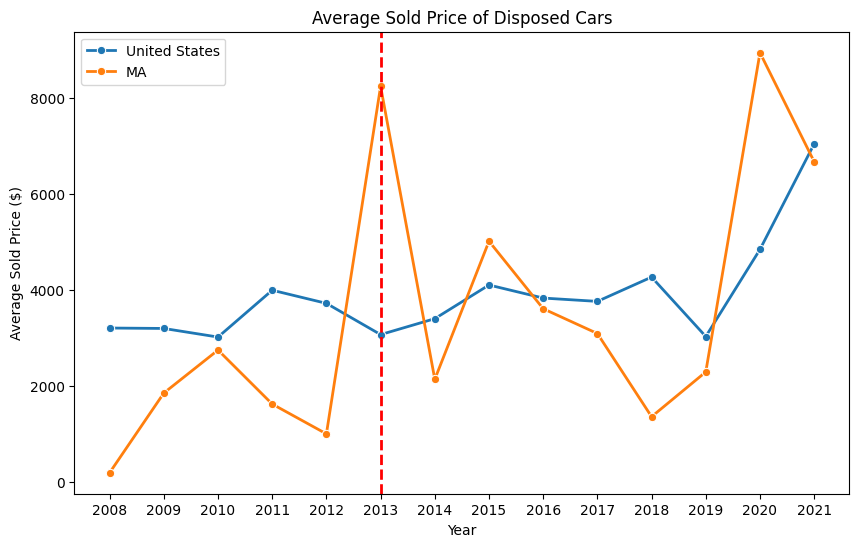

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = sold_price_yr_all, x = 'Year', y = ('SALEX', 'Mean Sold Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = sold_price_yr_MA, x = 'Year', y = ('SALEX', 'Mean Sold Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Average Sold Price of Disposed Cars')
plt.xlabel('Year')
plt.ylabel('Average Sold Price ($)')

- The outlier in 2013 affect the trend

Text(0, 0.5, 'Median Sold Price ($)')

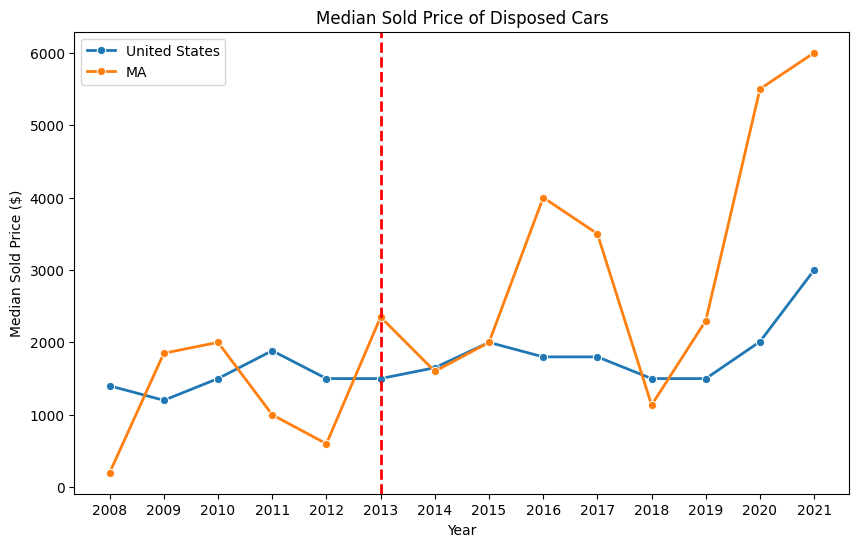

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = sold_price_yr_all, x = 'Year', y = ('SALEX', 'Median Sold Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = sold_price_yr_MA, x = 'Year', y = ('SALEX', 'Median Sold Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Median Sold Price of Disposed Cars')
plt.xlabel('Year')
plt.ylabel('Median Sold Price ($)')

### **Amount of Record**
- The sample size is too small that there may be outliers.

Text(0, 0.5, 'Count')

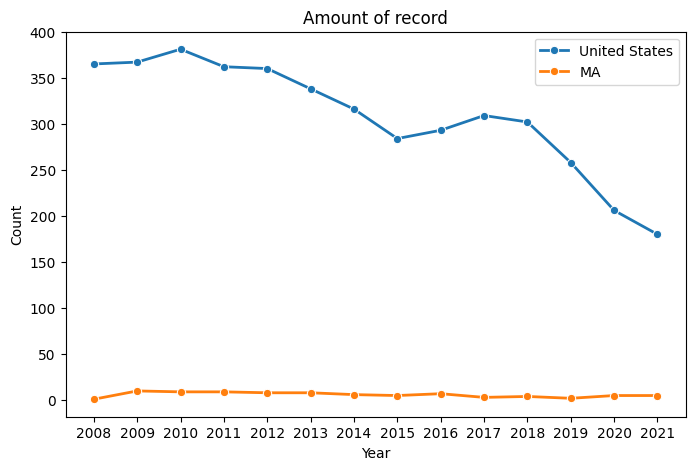

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data = sold_price_yr_all, x = 'Year', y = ('Household', 'Count'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = sold_price_yr_MA, x = 'Year', y = ('Household', 'Count'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.title('Amount of record')
plt.xlabel('Year')
plt.ylabel('Count')

**Sometime Interesting:** People were tending to sell their disposed car at the middle of the year (2nd quarter or the 3rd quarter).

## **4. Used Car Purchase**

Assumably, the used car price may increase as a used car may have better condition.

**Data Source:** OVB
- I used a filter to select owned vehicle which has the same purchase year as the year of survey and marked as used to get the used car purchase records.

**Findings:**
1. Used car purchase price drastically increased after 2013 and suddenly dropped in 2016, similar to the purchase price in other states of the US.

But, according to the following graphs, the trend of the purchase price of used car in MA resembles the trend of the purchase price of other states. Even though there are disparities between them, the lack of sample and the high proportion of null data in MA may be the reason for the noise.

### Get Purchase Function
- get_purchase_used(details)
- return a dataframe with year, quarter, the amount of used car purchase in each time period, the mean purchase price, and the median purchase price.

In [ ]:
def get_purchase_used(details):
  # VEHPURMO purchase month
  purchase = pd.DataFrame();
  null_proportion = pd.Series();
  household_w_null = pd.Series();
  prop_purchase = pd.Series();

  for yr in details.keys():
      raw = details[yr]['Bought_used'].copy()
      df = raw.loc[raw['NETPURX'] != -1]

      #get purchase price
      df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
      purchase_yr = df.groupby('Year').agg({'NETPURX': [('Mean Bought Price', 'mean'), ('Median Bought Price', 'median')], 'Household': [('Count', 'nunique')]}).reset_index()

      #get sample size (null purchase vs all purchase)
      null_proportion = pd.concat([null_proportion, pd.Series([raw.loc[raw['NETPURX'] == -1].shape[0] / raw.shape[0]])])

      #amount of household with null
      household_w_null = pd.concat([household_w_null, pd.Series([raw['Household'].nunique()])])

      #num of purchase / num of household
      num_household = details[yr]['Household_code'].shape[0]
      prop_purchase = pd.concat([prop_purchase, pd.Series([raw.shape[0] / num_household])])

      purchase = pd.concat([purchase, purchase_yr], axis = 0)

  purchase['Household (with null)'] = household_w_null
  purchase['Null Rate'] = null_proportion
  purchase['Purchase Rate'] = prop_purchase

  return purchase

### Run the Function

In [ ]:
purchase_used_MA = get_purchase_used(details_MA)
purchase_used_all = get_purchase_used(details_all)

<ipython-input-31-143ce90858b9>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-31-143ce90858b9>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-31-143ce90858b9>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'M

In [ ]:
purchase_used_MA

Year           NETPURX                     Household  \
          Mean Bought Price Median Bought Price     Count   
0  2008.0       9138.545455              7244.5        10   
0  2009.0       6459.597826              4830.0        20   
0  2010.0       8749.900000              8697.5        19   
0  2011.0      11421.190476              9000.0        18   
0  2012.0      10536.666667              8275.0        24   
0  2013.0       7581.300000              8250.0         7   
0  2014.0      12124.600000             10308.0        20   
0  2015.0      14220.100000             13500.0        10   
0  2016.0      10226.181818              7000.0        21   
0  2017.0      11123.619048              8000.0        20   
0  2018.0      13090.400000             13706.0        14   
0  2019.0      17544.818182             17500.0        22   
0  2020.0      16125.000000             17000.0        15   
0  2021.0      17976.529412             19000.0        15   

  Household (with null) Null Rate Purchase Rate  
                                                 
0                    15  0.388889      0.068182  
0                    21  0.041667      0.086331  
0                    25  0.259259      0.095070  
0                    21  0.160000      0.087108  
0                    26  0.111111      0.097122  
0                     8  0.090909      0.045082  
0                    25  0.230769      0.112554  
0                    15  0.375000      0.064777  
0                    24  0.153846      0.077381  
0                    27  0.300000      0.090634  
0                    18  0.210526      0.059375  
0                    27  0.241379      0.093851  
0                    18  0.210526      0.062295  
0                    19  0.227273      0.071895

In [ ]:
purchase_used_all

Year           NETPURX                     Household  \
          Mean Bought Price Median Bought Price     Count   
0  2008.0       9272.385957              6981.0       746   
0  2009.0       8413.792393              5623.5       820   
0  2010.0       8695.053729              6000.0       909   
0  2011.0       9395.151235              6420.0       846   
0  2012.0      10049.394108              7958.0       880   
0  2013.0      10382.375501              8000.0       795   
0  2014.0      10918.684432              8677.5       823   
0  2015.0      12096.992479             10000.0       891   
0  2016.0      11666.546784              9200.0       879   
0  2017.0      12188.401221             10200.0       807   
0  2018.0      13355.389324             10738.0       748   
0  2019.0      13228.910846             10815.0       731   
0  2020.0      15250.538168             13000.0       592   
0  2021.0      15711.823051             13000.0       629   

  Household (with null) Null Rate Purchase Rate  
                                                 
0                  1015  0.299914      0.099983  
0                  1050  0.243199      0.103463  
0                  1092  0.187400      0.104352  
0                  1037  0.193361      0.104158  
0                  1044  0.177741      0.104623  
0                   929  0.165428      0.096295  
0                  1003  0.196823      0.100532  
0                  1127  0.234093      0.114623  
0                  1112  0.242377      0.109955  
0                  1031  0.242857      0.105412  
0                   966  0.244303      0.103539  
0                   941  0.240930      0.107157  
0                   773  0.266517      0.089614  
0                   813  0.257721      0.093526

### **Used Car Purchase Price**

Text(0, 0.5, 'Median Purchase Price ($)')

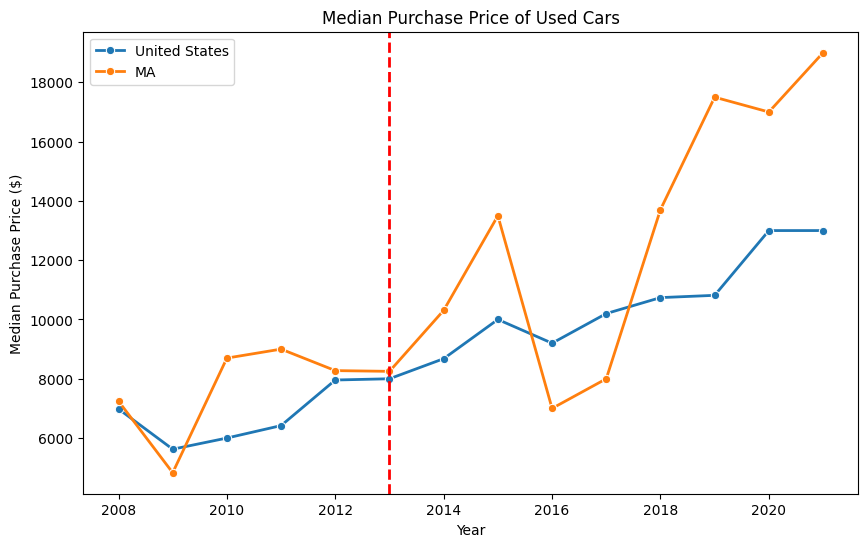

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_used_all, x = 'Year', y = ('NETPURX', 'Median Bought Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_used_MA, x = 'Year', y = ('NETPURX', 'Median Bought Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Median Purchase Price of Used Cars')
plt.xlabel('Year')
plt.ylabel('Median Purchase Price ($)')

Text(0, 0.5, 'Mean Purchase Price ($)')

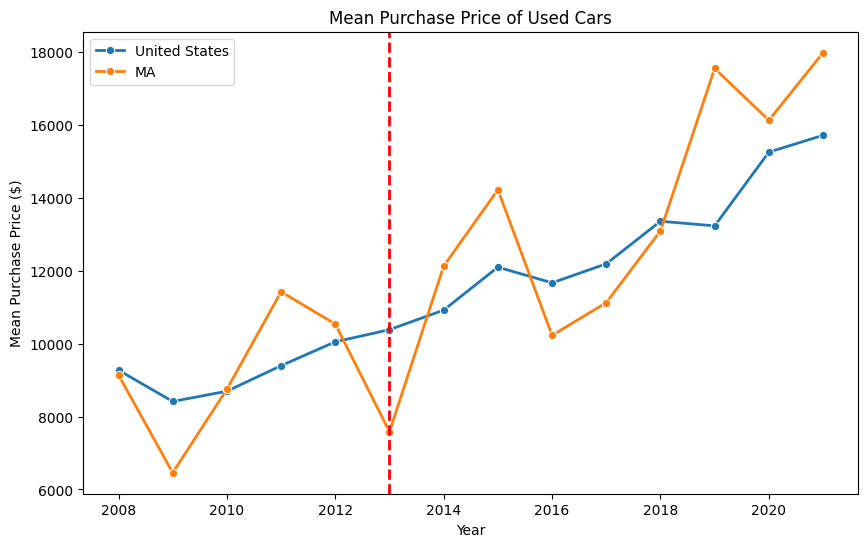

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_used_all, x = 'Year', y = ('NETPURX', 'Mean Bought Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_used_MA, x = 'Year', y = ('NETPURX', 'Mean Bought Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Mean Purchase Price of Used Cars')
plt.xlabel('Year')
plt.ylabel('Mean Purchase Price ($)')

### **Amount of Used Car Purchase**

Text(0, 0.5, 'Count')

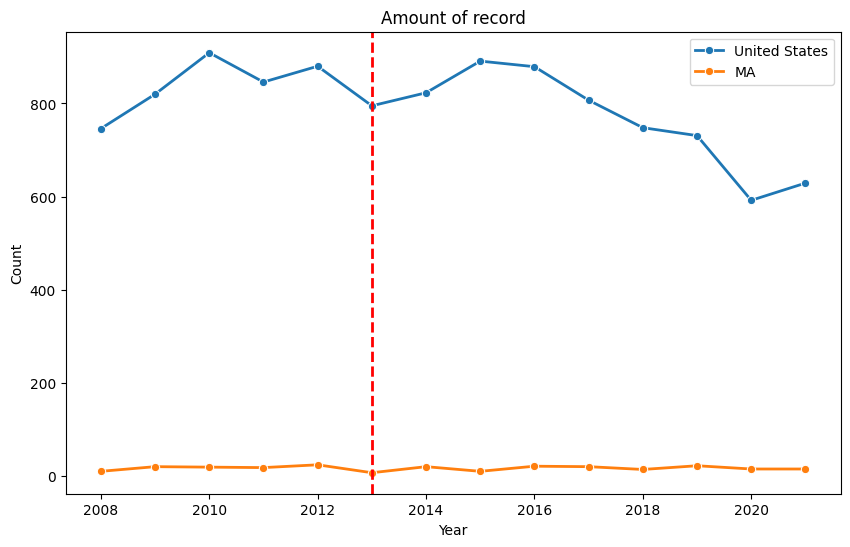

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_used_all, x = 'Year', y = ('Household', 'Count'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_used_MA, x = 'Year', y = ('Household', 'Count'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Amount of record')
plt.xlabel('Year')
plt.ylabel('Count')

### **Discovering the Sample**

(0.0, 0.5)

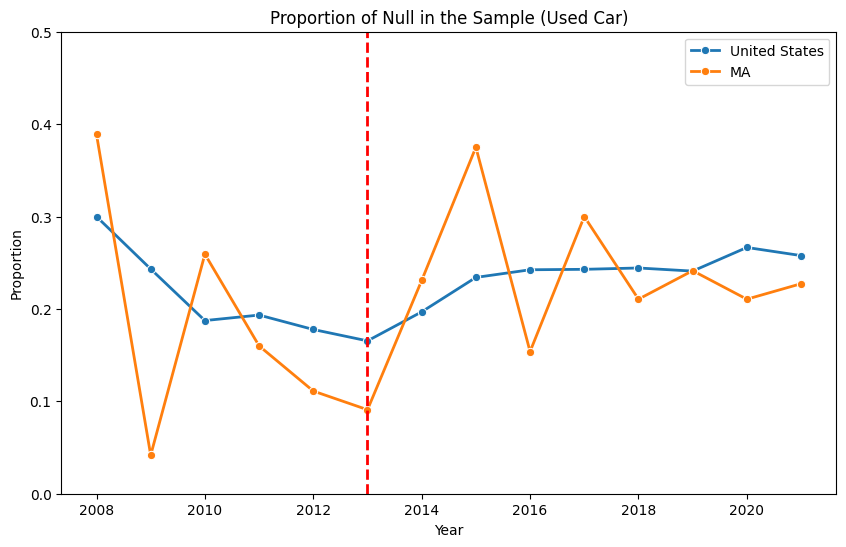

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_used_all, x = 'Year', y = 'Null Rate', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_used_MA, x = 'Year', y = 'Null Rate', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Proportion of Null in the Sample (Used Car)')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim((0, 0.5))

(0.0, 0.3)

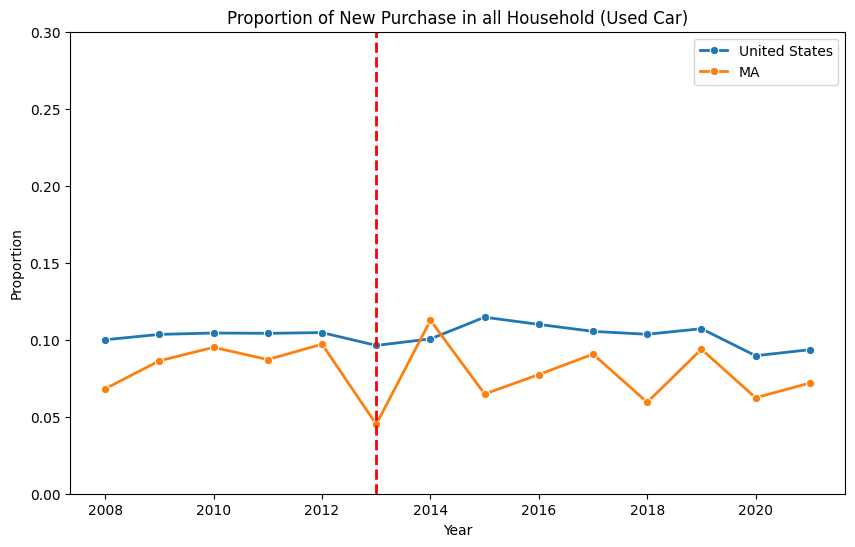

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_used_all, x = 'Year', y = 'Purchase Rate', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_used_MA, x = 'Year', y = 'Purchase Rate', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Proportion of New Purchase in all Household (Used Car)')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim((0, 0.3))

## **5. All Car Purchase**

Since we lack the sample for used car purchase, combining new car purchase and used car purchase may be a better way to observe the market without bias. As the vehicle ownership decreased, I would expect the car purchase instance decrease as well to match the result in part one.

**Data Source:** OVB
- I used a filter to select owned vehicle which has the same purchase year as the year of survey to get the car purchase records.

**Findings:**
1. Purchase price increased in 2014, then dropped in 2016. It then reached an apex in 2019.
2. Average number of purchase per household decreased after 2014.

By looking into the graphs, I observed a clear divergence between MA's and other states' average number of purchase per household after 2014. Households in MA were making less purchase, which conforms to the phenomenon of decreasing ownership in part one.

### Get Purchase Function
- get_purchase(details)
- return a dataframe with year, quarter, the amount of all car purchase in each time period, the mean purchase price, and the median purchase price.

In [ ]:
def get_purchase(details):
  # VEHPURMO purchase month
  purchase = pd.DataFrame();
  null_proportion = pd.Series();
  household_w_null = pd.Series();
  avg_purchase = pd.Series();

  for yr in details.keys():
      raw = details[yr]['Bought'].copy()
      df = raw.loc[raw['NETPURX'] != -1]

      #get purchase price
      df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
      purchase_yr = df.groupby('Year').agg({'NETPURX': [('Mean Bought Price', 'mean'), ('Median Bought Price', 'median')], 'Household': [('Count', 'nunique')]}).reset_index()

      #get sample size (null purchase vs all purchase)
      null_proportion = pd.concat([null_proportion, pd.Series([raw.loc[raw['NETPURX'] == -1].shape[0] / raw.shape[0]])])

      #amount of household with null
      household_w_null = pd.concat([household_w_null, pd.Series([raw['Household'].nunique()])])

      #num of purchase / num of household (avg purchase)
      num_household = details[yr]['Household_code'].shape[0]
      avg_purchase = pd.concat([avg_purchase, pd.Series([raw.shape[0] / num_household])])

      purchase = pd.concat([purchase, purchase_yr], axis = 0)

  purchase['Household (with null)'] = household_w_null
  purchase['Null Rate'] = null_proportion
  purchase['Average Number of Purchase'] = avg_purchase

  return purchase

### Run the Function

In [ ]:
purchase_MA = get_purchase(details_MA)
purchase_all = get_purchase(details_all)

<ipython-input-40-531ba15f14b9>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-40-531ba15f14b9>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-40-531ba15f14b9>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'M

In [ ]:
purchase_MA

Year           NETPURX                     Household  \
          Mean Bought Price Median Bought Price     Count   
0  2008.0      12479.625000            11228.50        15   
0  2009.0      12920.344595            13000.00        34   
0  2010.0      15553.875000            15999.75        32   
0  2011.0      16700.566667            15853.00        27   
0  2012.0      16185.939394            13000.00        31   
0  2013.0      18136.208333            16265.50        20   
0  2014.0      15532.482759            16000.00        29   
0  2015.0      22430.714286            22844.00        21   
0  2016.0      14811.937500            15450.00        30   
0  2017.0      13947.555556            14300.00        26   
0  2018.0      20350.241379            19000.00        27   
0  2019.0      23040.595960            20000.00        30   
0  2020.0      21399.347826            19656.00        23   
0  2021.0      17578.304348            19000.00        21   

  Household (with null) Null Rate Average Number of Purchase  
                                                              
0                    22  0.360000                   0.094697  
0                    37  0.075000                   0.143885  
0                    39  0.181818                   0.154930  
0                    30  0.142857                   0.121951  
0                    34  0.131579                   0.136691  
0                    21  0.040000                   0.102459  
0                    35  0.194444                   0.155844  
0                    27  0.275862                   0.117409  
0                    33  0.111111                   0.107143  
0                    34  0.270270                   0.111782  
0                    32  0.147059                   0.106250  
0                    36  0.195122                   0.132686  
0                    27  0.178571                   0.091803  
0                    27  0.233333                   0.098039

In [ ]:
purchase_all
# exclude MA

Year           NETPURX                     Household  \
          Mean Bought Price Median Bought Price     Count   
0  2008.0      13541.335062        11500.000000      1035   
0  2009.0      12897.152244        10999.833333      1164   
0  2010.0      12964.837436        10500.000000      1213   
0  2011.0      14012.125856        12000.000000      1149   
0  2012.0      14838.361131        13038.000000      1250   
0  2013.0      15019.147264        13000.000000      1129   
0  2014.0      16155.741204        14700.000000      1148   
0  2015.0      17181.807958        16000.000000      1269   
0  2016.0      16713.979320        14905.000000      1238   
0  2017.0      17820.623143        15600.000000      1150   
0  2018.0      18883.238722        17300.000000      1083   
0  2019.0      18355.281500        16480.000000      1016   
0  2020.0      21302.977825        19075.000000       858   
0  2021.0      22755.455753        20000.000000       891   

  Household (with null) Null Rate Average Number of Purchase  
                                                              
0                  1447  0.317881                   0.143536  
0                  1464  0.224344                   0.142955  
0                  1437  0.178140                   0.137805  
0                  1396  0.189273                   0.140202  
0                  1478  0.177126                   0.148158  
0                  1319  0.164347                   0.135046  
0                  1392  0.189480                   0.140018  
0                  1558  0.210497                   0.159553  
0                  1509  0.213626                   0.148900  
0                  1441  0.230908                   0.147312  
0                  1356  0.221717                   0.145163  
0                  1291  0.233333                   0.146531  
0                  1094  0.248413                   0.126443  
0                  1135  0.242890                   0.129582

### **Car Purchase Price (without Null)**
- both new and used cars

Text(0, 0.5, 'Median Purchase Price ($)')

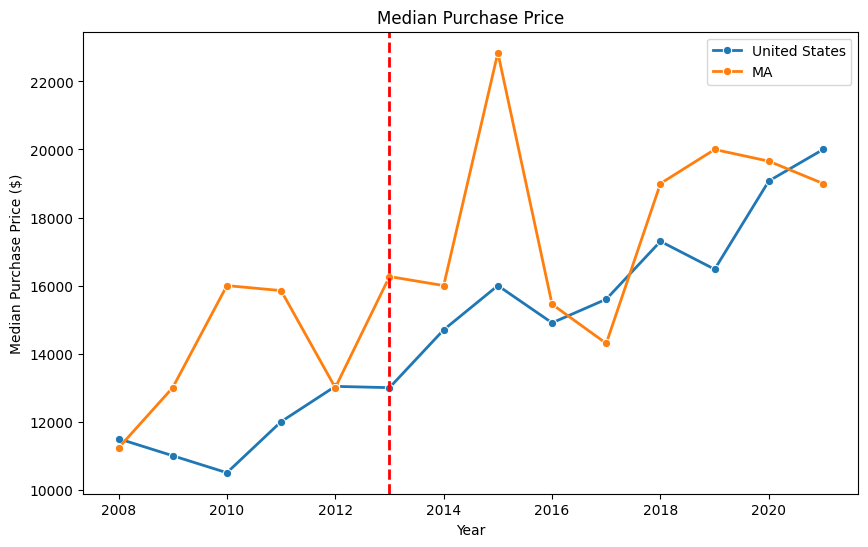

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_all, x = 'Year', y = ('NETPURX', 'Median Bought Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_MA, x = 'Year', y = ('NETPURX', 'Median Bought Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Median Purchase Price')
plt.xlabel('Year')
plt.ylabel('Median Purchase Price ($)')

Text(0, 0.5, 'Mean Purchase Price ($)')

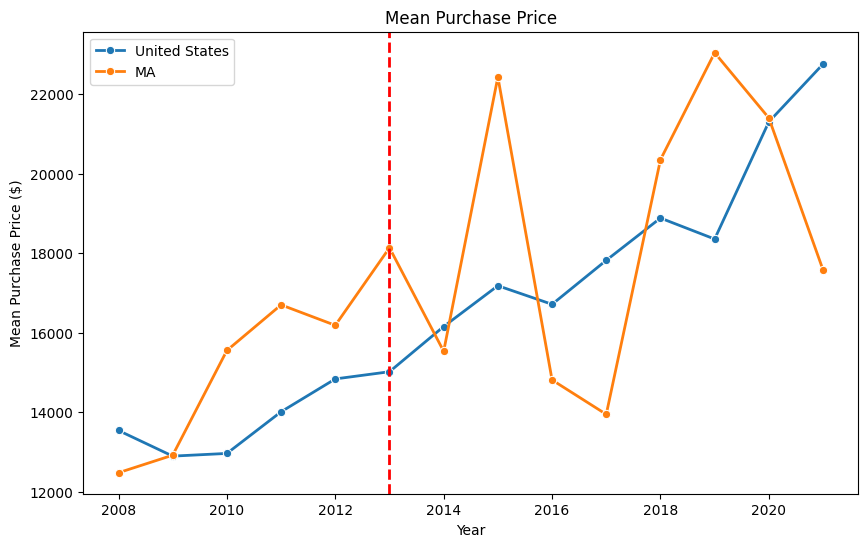

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_all, x = 'Year', y = ('NETPURX', 'Mean Bought Price'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_MA, x = 'Year', y = ('NETPURX', 'Mean Bought Price'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Mean Purchase Price')
plt.xlabel('Year')
plt.ylabel('Mean Purchase Price ($)')

### **Discovering the Sample**

(0.0, 0.3)

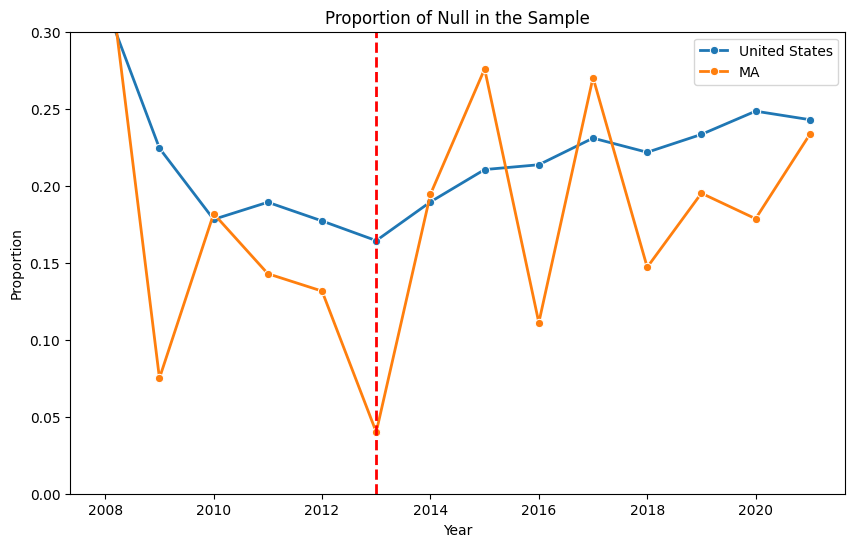

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_all, x = 'Year', y = 'Null Rate', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_MA, x = 'Year', y = 'Null Rate', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Proportion of Null in the Sample')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim((0, 0.3))

### **Average Number of Purchase**
- Average Number of Purchase per Household

(0.0, 0.3)

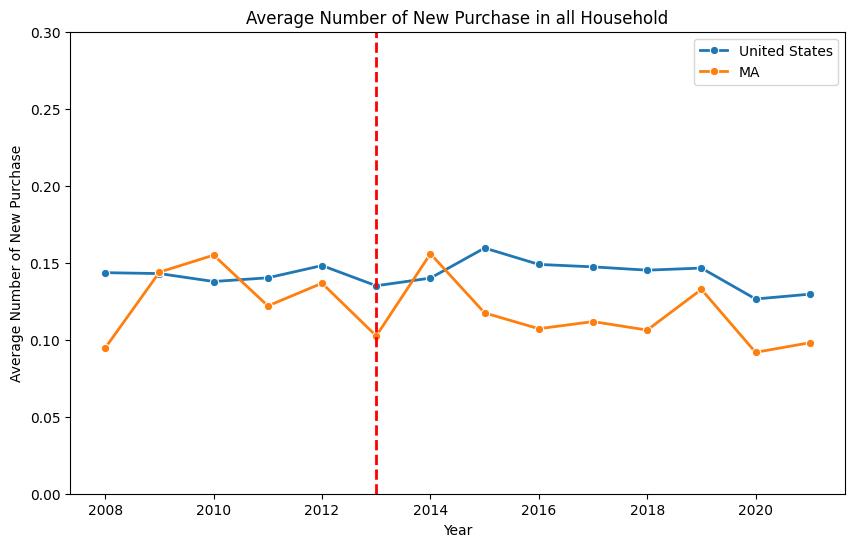

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = purchase_all, x = 'Year', y = 'Average Number of Purchase', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = purchase_MA, x = 'Year', y = 'Average Number of Purchase', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Average Number of New Purchase in all Household')
plt.xlabel('Year')
plt.ylabel('Average Number of New Purchase')
plt.ylim((0, 0.3))

## **6. Vehicle Disposal**

Since the repair law would enhance the accessibility of reparing vehicles, households may be less willing to dispose their car with better condition. To verify this assumption, I looked into the change of proportion of each disposal type to see how people react to the repair law when disposing their vehicles.

**Data Source:** OVC
- OVC contains records of all vehicle disposal for each household.

**Findings:**
1. The average number of disposal in MA doesn't divert too much from the trend of other states before 2015, but it became smaller than that of other states after 2015.
2. The proportion of trade-in in all disposal instances in MA increased drastically after 2012, which is very different from the decreasing trend of other states in the US.

The first finding is quite intuitive, since the repair law may help people to reapir their vehicle, people would not easily dispose their car with good condition.
In contrast, the second finding is quite interesting as seemingly there's barely a connection between trade-in and the repair law. I guess it's because trade-in vehicles with good condition can attain a greater discount, which motivated the households to trade-in their vehicles.

### Get Disposal Function
- get_disposal(details)
- return a dataframe with year, the percentage of each type of disposal, and the porportion of disposal compared to the number of household.

In [ ]:
def get_disposal(details):
  disposal = pd.DataFrame();

  sold_percent = pd.Series();
  damage_percent = pd.Series();
  tradein_percent = pd.Series();
  giveaway_percent = pd.Series();
  stolen_percent = pd.Series();
  other_percent = pd.Series();

  all_count = pd.Series();
  avg_disposal = pd.Series();

  # types = ['Sold', 'Damage', 'Tradein', 'Giveaway', 'Stolen', 'Other']

  for yr in details.keys():
    all = details[yr]['Sold'].shape[0] + details[yr]['Damage'].shape[0] + details[yr]['Tradein'].shape[0] + details[yr]['Giveaway'].shape[0] + details[yr]['Stolen'].shape[0] + details[yr]['Other'].shape[0]

    sold_percent = pd.concat([sold_percent, pd.Series([details[yr]['Sold'].shape[0] / all])], ignore_index=True)
    damage_percent = pd.concat([damage_percent, pd.Series([details[yr]['Damage'].shape[0] / all])], ignore_index=True)
    tradein_percent = pd.concat([tradein_percent, pd.Series([details[yr]['Tradein'].shape[0] / all])], ignore_index=True)
    giveaway_percent = pd.concat([giveaway_percent, pd.Series([details[yr]['Giveaway'].shape[0] / all])], ignore_index=True)
    stolen_percent = pd.concat([stolen_percent, pd.Series([details[yr]['Stolen'].shape[0] / all])], ignore_index=True)
    other_percent = pd.concat([other_percent, pd.Series([details[yr]['Other'].shape[0] / all])], ignore_index=True)

    # disposed_household = pd.concat([details[yr]['Sold']['Household'],
    #                                 details[yr]['Damage']['Household'],
    #                                 details[yr]['Tradein']['Household'],
    #                                 details[yr]['Giveaway']['Household'],
    #                                 details[yr]['Stolen']['Household'],
    #                                 details[yr]['Other']['Household']],
    #                                ignore_index = True).nunique()

    #avg number of disposal
    avg_disposal = pd.concat([avg_disposal, pd.Series([all / details[yr]['Household_code'].shape[0]])], ignore_index=True)
    all_count = pd.concat([all_count, pd.Series([all])], ignore_index=True)

  disposal['Year'] = '20' + pd.Series(details.keys())
  disposal['Sold %'] = sold_percent
  disposal['Damage %'] = damage_percent
  disposal['Tradein %'] = tradein_percent
  disposal['Giveaway %'] = giveaway_percent
  disposal['Stolen %'] = stolen_percent
  disposal['Other %'] = other_percent
  disposal['Amount of Disposal'] = all_count
  disposal['Average Number of Disposal'] = avg_disposal

  return disposal

### Run the Function

In [ ]:
disposal_MA = get_disposal(details_MA)
disposal_all = get_disposal(details_all)

In [ ]:
disposal_MA

,Year,Sold %,Damage %,Tradein %,Giveaway %,Stolen %,Other %,Amount of Disposal,Average Number of Disposal
0,2008,0.068966,0.068966,0.379310,0.206897,0.0,0.275862,29,0.109848
1,2009,0.255814,0.069767,0.279070,0.186047,0.0,0.209302,43,0.154676
2,2010,0.257143,0.028571,0.371429,0.200000,0.0,0.142857,35,0.123239
3,2011,0.275000,0.175000,0.325000,0.175000,0.0,0.050000,40,0.139373
4,2012,0.242424,0.121212,0.303030,0.212121,0.0,0.121212,33,0.118705
5,2013,0.354839,0.000000,0.387097,0.193548,0.0,0.064516,31,0.127049
6,2014,0.193548,0.064516,0.419355,0.129032,0.0,0.193548,31,0.134199
7,2015,0.192308,0.076923,0.538462,0.192308,0.0,0.000000,26,0.105263
8,2016,0.242424,0.060606,0.454545,0.181818,0.0,0.060606,33,0.098214
9,2017,0.111111,0.222222,0.333333,0.111111,0.0,0.222222,27,0.081571


In [ ]:
disposal_all
# exclude MA

,Year,Sold %,Damage %,Tradein %,Giveaway %,Stolen %,Other %,Amount of Disposal,Average Number of Disposal
0,2008,0.273537,0.115140,0.247455,0.139949,0.008906,0.215013,1572,0.135845
1,2009,0.271544,0.101054,0.249225,0.146311,0.004960,0.226906,1613,0.137581
2,2010,0.283215,0.112767,0.241089,0.141283,0.007777,0.213869,1543,0.128401
3,2011,0.283401,0.124831,0.256410,0.120108,0.007422,0.207827,1482,0.128101
4,2012,0.266187,0.108568,0.293002,0.134075,0.005886,0.192283,1529,0.132864
5,2013,0.265306,0.119728,0.310204,0.118367,0.007483,0.178912,1470,0.131555
6,2014,0.257651,0.130961,0.313167,0.121708,0.004270,0.172242,1405,0.124667
7,2015,0.282481,0.118189,0.289187,0.142498,0.008382,0.159262,1193,0.107419
8,2016,0.284028,0.129032,0.265932,0.136113,0.006294,0.178600,1271,0.109268
9,2017,0.298300,0.131376,0.234158,0.163060,0.003864,0.169243,1294,0.114625


### **Average Number of Disposal**
- Average number of disposal per household

(0.0, 0.2)

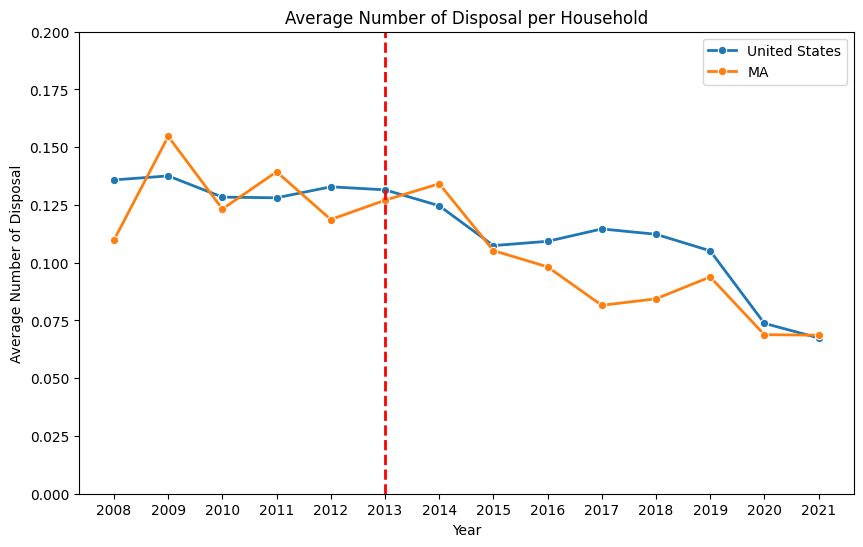

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = disposal_all, x = 'Year', y = 'Average Number of Disposal', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Average Number of Disposal', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Average Number of Disposal per Household')
plt.xlabel('Year')
plt.ylabel('Average Number of Disposal')
plt.ylim(0, 0.2)

### **Proportion of Different Types of Disposal**

(0.0, 0.6)

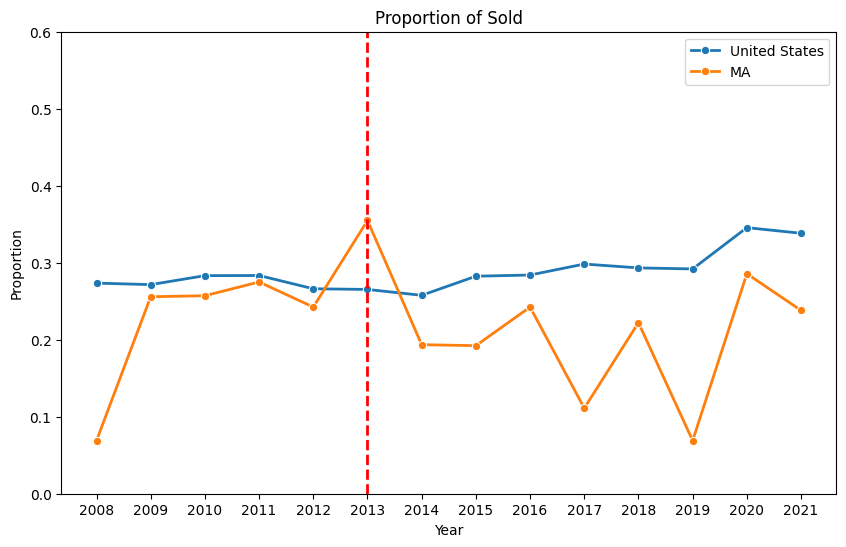

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = disposal_all, x = 'Year', y = 'Sold %', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Sold %', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Proportion of Sold')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim(0, 0.6)
# duplicates

(0.0, 0.6)

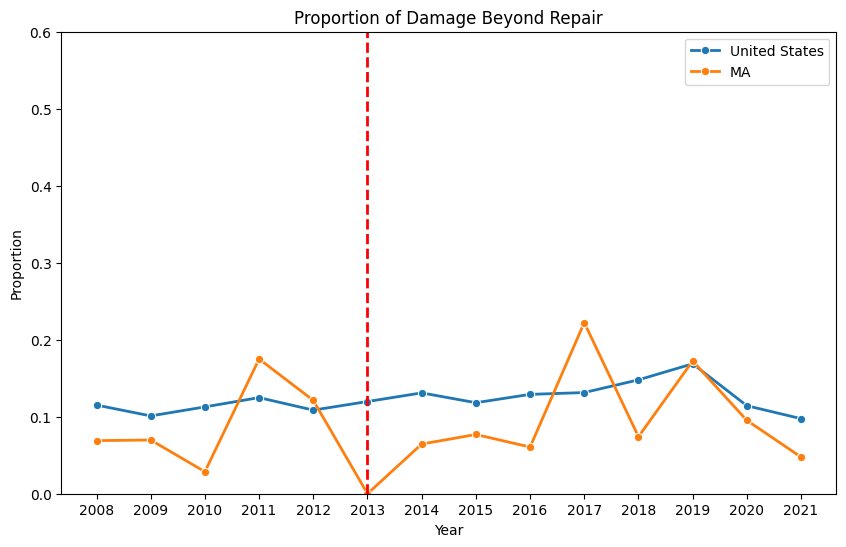

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = disposal_all, x = 'Year', y = 'Damage %', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Damage %', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Proportion of Damage Beyond Repair')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim(0, 0.6)

(0.0, 0.6)

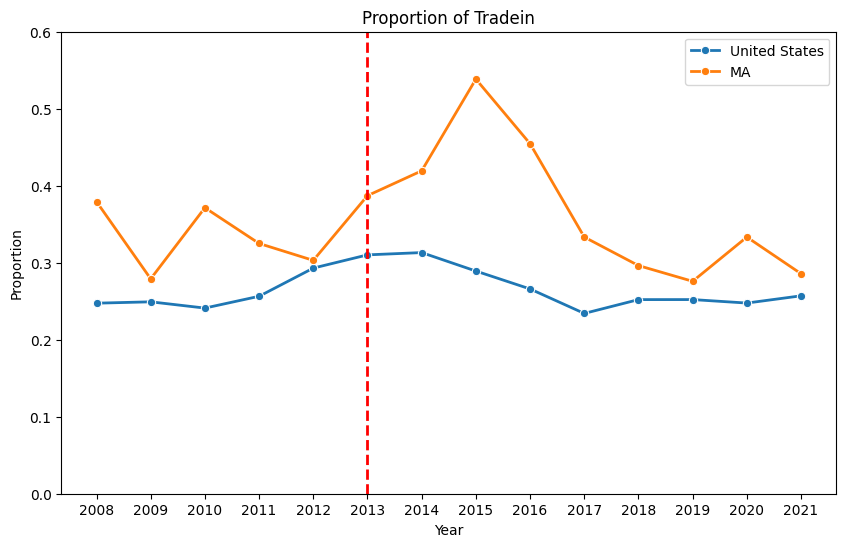

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = disposal_all, x = 'Year', y = 'Tradein %', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Tradein %', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Proportion of Tradein')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim(0, 0.6)

(0.0, 0.6)

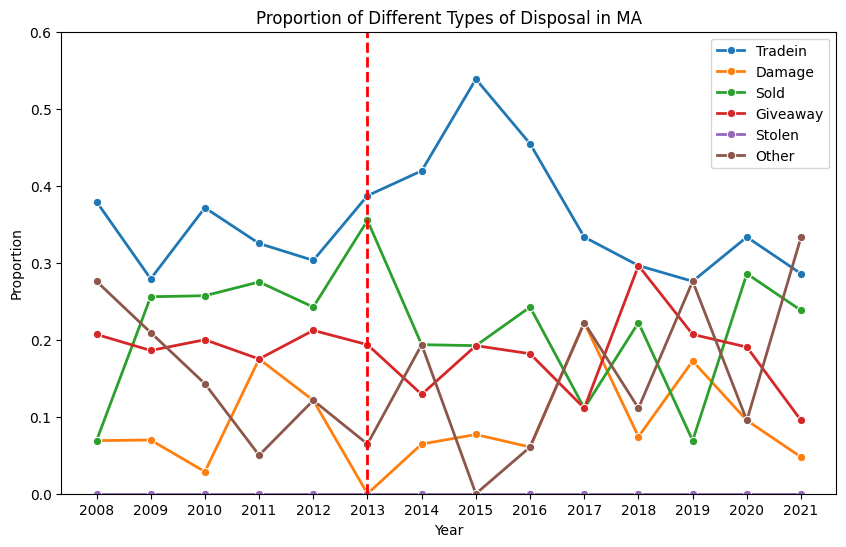

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = disposal_MA, x = 'Year', y = 'Tradein %', label = 'Tradein', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Damage %', label = 'Damage', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Sold %', label = 'Sold', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Giveaway %', label = 'Giveaway', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Stolen %', label = 'Stolen', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = disposal_MA, x = 'Year', y = 'Other %', label = 'Other', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline('2013', color='red', linestyle='--', linewidth=2)
plt.title('Proportion of Different Types of Disposal in MA')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim(0, 0.6)

## **7. Used Car Trade-In**

To verify my assumption in the previous section, I looked into the amount of trade-in allowance (amount of trade-in discount). If the trade-in allowance increased, then people would have greater motivation to trade-in their cars.

**Data Source:** OVB
- To see how people behave (trade-in or not) when they are actually making a purchase, I used the purchase data by filtering the OVB to get the amount of trade-in allowance.

**Findings:**
1. The median trade-in allowance in MA didn't increase after 2014.
2. After 2012, the proportion of household trade-in their vehicle when making a purchase increased until 2015.

It's bizarre that with a non-increasing trade-in allowance, the proportion of trade-in in vehicle disposal increased. An alternate explanation for this is that since the proportion of trade-in is a proportion than an instance variable, it doesn't indicate that its increase means people are more willing to trade-in their car.

### Get Tradein Function
- get_tradein(details)
- return a dataframe containing the year, the average tradein discount, and the median tradein discount of disposed cars at that year.

In [ ]:
def get_tradein(details):
  # VEHPURMO purchase month
  tradein = pd.DataFrame();
  tradein_rate = pd.Series();

  for yr in details.keys():
      raw = details[yr]['Bought'].copy()
      df = raw.loc[raw['TRADEX'] != -1]

      #get tradein allowance amount
      df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
      tradein_yr = df.groupby('Year').agg({'TRADEX': [('Mean Trade-In Amount', 'mean'), ('Median Trade-In Amount', 'median')], 'Household': [('Count', 'nunique')]}).reset_index()

      #num of tradein / num of purchase
      # num_household = details[yr]['Household_code'].shape[0]
      tradein_rate = pd.concat([tradein_rate, pd.Series([df.shape[0] / raw.shape[0]])])

      tradein = pd.concat([tradein, tradein_yr], axis = 0)

  tradein['Trade-In Rate'] = tradein_rate

  return tradein

### Run the Function

In [ ]:
tradein_MA = get_tradein(details_MA)
tradein_all = get_tradein(details_all)

<ipython-input-57-647087f8e5c4>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-57-647087f8e5c4>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
<ipython-input-57-647087f8e5c4>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'VEHPURMO': 'M

In [ ]:
tradein_MA

Year               TRADEX                        Household Trade-In Rate
          Mean Trade-In Amount Median Trade-In Amount     Count              
0  2008.0          2871.000000                 2000.0         5      0.200000
0  2009.0          3959.966667                 2000.0        15      0.375000
0  2010.0          5052.970588                 3000.0        17      0.386364
0  2011.0          5700.000000                 4000.0        12      0.371429
0  2012.0          3678.571429                 2700.0        10      0.289474
0  2013.0          4672.200000                 3800.0        13      0.600000
0  2014.0          4229.411765                 2000.0        17      0.472222
0  2015.0          2559.312500                 1000.0        16      0.551724
0  2016.0          6333.333333                 2000.0        15      0.416667
0  2017.0          3933.333333                 2000.0         9      0.243243
0  2018.0          3409.090909                 3000.0        10      0.323529
0  2019.0          5073.227273                 1500.0        10      0.268293
0  2020.0          8537.500000                 7400.0         8      0.285714
0  2021.0         11740.000000                 7500.0        10      0.333333

In [ ]:
tradein_all

Year               TRADEX                        Household Trade-In Rate
          Mean Trade-In Amount Median Trade-In Amount     Count              
0  2008.0          5483.457459                 3850.0       273      0.172185
0  2009.0          5238.551643                 3500.0       399      0.254177
0  2010.0          6342.883784                 4000.0       355      0.223430
0  2011.0          6729.591204                 4000.0       329      0.221948
0  2012.0          7034.080854                 5000.0       408      0.256305
0  2013.0          6433.296539                 4000.0       389      0.277667
0  2014.0          6639.629326                 4000.0       341      0.231939
0  2015.0          6700.029788                 4200.0       434      0.257336
0  2016.0          7073.669571                 4000.0       363      0.215358
0  2017.0          7540.930633                 4500.0       337      0.215274
0  2018.0          7631.550147                 4900.0       323      0.220416
0  2019.0          6599.168939                 4500.0       311      0.224490
0  2020.0          6791.119722                 4000.0       282      0.238095
0  2021.0          9866.672445                 6000.0       267      0.210607

### **Amount of Trade-In Allowance**

(0.0, 10000.0)

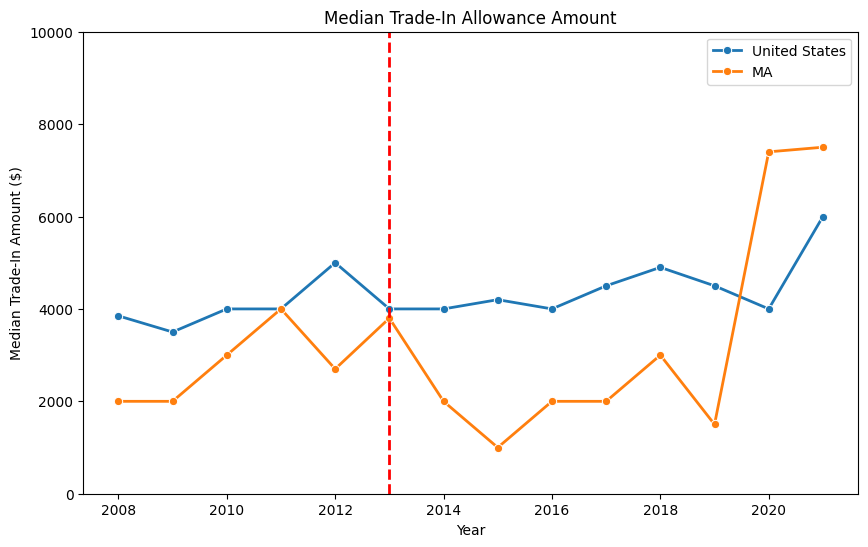

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = tradein_all, x = 'Year', y = ('TRADEX', 'Median Trade-In Amount'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = tradein_MA, x = 'Year', y = ('TRADEX', 'Median Trade-In Amount'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Median Trade-In Allowance Amount')
plt.xlabel('Year')
plt.ylabel('Median Trade-In Amount ($)')
plt.ylim((0, 10000))

(0.0, 10000.0)

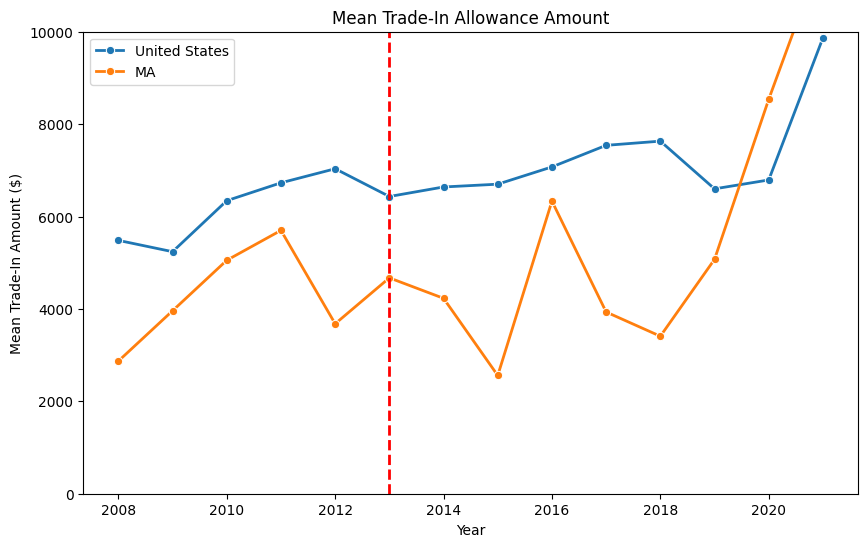

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = tradein_all, x = 'Year', y = ('TRADEX', 'Mean Trade-In Amount'), label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = tradein_MA, x = 'Year', y = ('TRADEX', 'Mean Trade-In Amount'), label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Mean Trade-In Allowance Amount')
plt.xlabel('Year')
plt.ylabel('Mean Trade-In Amount ($)')
plt.ylim((0, 10000))

### **Trade-In Rate**
- what proportion of household trade in when making an purchase

(0.0, 1.0)

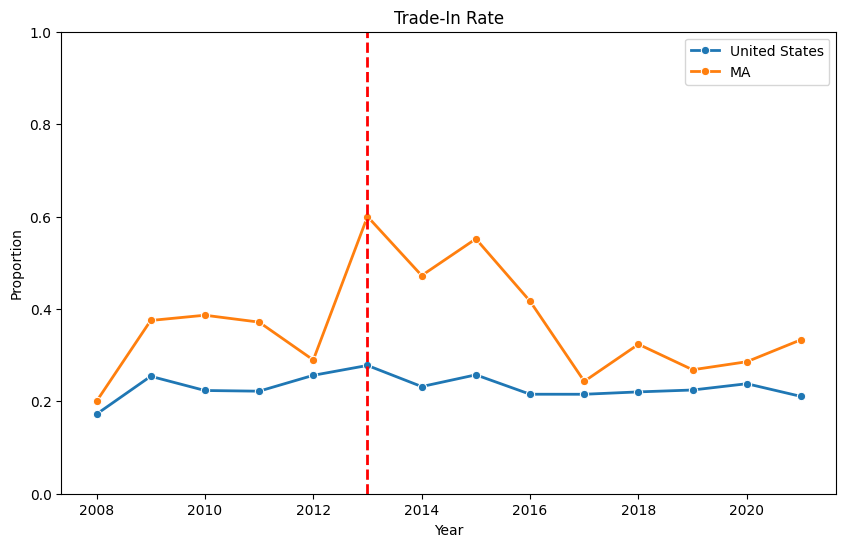

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data = tradein_all, x = 'Year', y = 'Trade-In Rate', label = 'United States', marker='o', linestyle='-', linewidth=2)
sns.lineplot(data = tradein_MA, x = 'Year', y = 'Trade-In Rate', label = 'MA', marker='o', linestyle='-', linewidth=2)

plt.legend()
plt.axvline(2013, color='red', linestyle='--', linewidth=2)
plt.title('Trade-In Rate')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.ylim((0, 1))

# **DID Analysis**
According to the emphirical analysis above, I chose to use DID analysis to evaluate these three potential anomalies after the repair law:
- **Logistic Regression:** Trade-in or not (rate of trade-in per purchase)
- **Linear Regression:** New purchase instance (average number of new purchase made by per household)
- **Linear Regression:** Vehicle Ownership (number of vehicle owned by a household)

The equation I used for the DID analysis is:

\begin{equation}
Y_{it} = \beta_0 + \beta_1 \text{Treatment}_i + \beta_2 \text{Post}_t + \beta_3 (\text{Treatment}_i \times \text{Post}_t) + \epsilon_{it}
\end{equation}

## **Logistic Regression: Trade-in or not**
- Y: trade in or not for a new purchase
- X: index, in/not in MA (Treatment), before/after 2014 (Post), Treatment * Post
- **Time Range:** 2010 - 2019

### Data Pipeline
- a function that returns the dataframe for the DID analysis.

In [ ]:
def pipe_tradein(details_MA, details_all):
  # VEHPURMO purchase month
  X = pd.DataFrame();
  y = pd.Series();

  n = 0

  for details in [details_MA, details_all]:
    X_state = pd.DataFrame()
    y_state = pd.Series()

    for yr in details.keys():
      raw = details[yr]['Bought'].copy()
      raw.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
      raw = raw.loc[(raw['Year'] <= 2019) & (raw['Year'] >= 2010)]

      # get post
      post = raw['Year'] >= 2014
      X_state = pd.concat([X_state, pd.DataFrame(data = {'Post': post})], axis = 0)

      # get y
      y_state = pd.concat([y_state, raw['TRADEX'] != -1])

    # get treatment
    if n == 0:
      X_state['Treatment'] = 1
      n += 1
    else:
      X_state['Treatment'] = 0

    # get treatment * post
    X_state['Treatment * Post'] = X_state['Treatment'] * X_state['Post']

    # concat state to the return dataset
    X = pd.concat([X, X_state], axis = 0)
    y = pd.concat([y, y_state])

  X['Treatment'] = X['Treatment'].astype('int')
  X['Post'] = X['Post'].astype('int')
  X['Treatment * Post'] = X['Treatment * Post'].astype('int')
  y = y.astype('int')

  return X, y

### Run the Function

In [ ]:
X_tradein, y_tradein = pipe_tradein(details_MA=details_MA, details_all=details_all)

In [ ]:
X_tradein.head()

,Post,Treatment,Treatment * Post
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [ ]:
y_tradein[y_tradein == 0].shape

(12657,)

### Modeling

In [ ]:
import statsmodels.api as sm
X_t = sm.add_constant(X_tradein)
log_reg = sm.Logit(y_tradein, X_t).fit()

Optimization terminated successfully.
         Current function value: 0.546927
         Iterations 5


In [ ]:
print(log_reg.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                16600
Model:                          Logit   Df Residuals:                    16596
Method:                           MLE   Df Model:                            3
Date:                Fri, 24 May 2024   Pseudo R-squ.:                0.002352
Time:                        05:03:33   Log-Likelihood:                -9079.0
converged:                       True   LL-Null:                       -9100.4
Covariance Type:            nonrobust   LLR p-value:                 2.706e-09
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.1292      0.029    -39.094      0.000      -1.186      -1.073
Post                -0.0914      0.038     -2.427      0.015      -0.165      -0.018
Treatment            0.7002 

### **Conclusion**
- I wanted to check how the repair law affected trade-in since the proportion of disposal type of trade-in increased drastically after 2014.
- To analysis whether the repair law affected consumers' willingness to trade-in, I implemented a logistic model to fit the data since y is a binary variable.
- According to the p value of Treatment * Post, it's unlikely that the repair loaw affect the willingness of trade-in. To explain the increase in proportion of trade-in disposal type, I assume that it might because other types of disposal decrease after 2014 while the number of trade-in remain stable.

## **Linear/Poisson Regression: New Purchase Instance**
- Y: number of purchase made by a household
- X: index, in/not in MA (Treatment), before/after 2014 (Post), Treatment * Post
- **Time Range:** 2010 - 2019

### Data Pipeline
- a function that returns the dataframe for the DID analysis.

In [ ]:
def pipe_purchase(details_MA, details_all):
  # VEHPURMO purchase month
  X = pd.DataFrame()
  y = pd.Series()
  n = 0


  for details in [details_MA, details_all]:
    X_state = pd.DataFrame()
    y_state = pd.Series()

    for yr in details.keys():
      raw = details[yr]['Bought'].copy()
      raw.rename(columns = {'VEHPURMO': 'Month', 'VEHPURYR': 'Year'}, inplace = True)
      raw = raw.loc[(raw['Year'] <= 2019) & (raw['Year'] >= 2010)]

      all_household = details[yr]['Household_code'].copy()

      # get number of unique purchase per household
      df = raw.groupby('Household')['Household'].count()

      # get post
      post = pd.Series([int(yr) >= 14] * all_household.shape[0])
      X_state = pd.concat([X_state, pd.DataFrame(data = {'Post': post})], axis = 0)

      # get y
      y_state = pd.concat([y_state, df])
      y_state = pd.concat([y_state, pd.Series([0] * (all_household.shape[0] - df.shape[0]))])


    # get treatment
    if n == 0:
      X_state['Treatment'] = 1
      n += 1
    else:
      X_state['Treatment'] = 0

    # get treatment * post
    X_state['Treatment * Post'] = X_state['Treatment'] * X_state['Post']

    # concat state to the return dataset
    X = pd.concat([X, X_state], axis = 0)
    y = pd.concat([y, y_state])

  X['Treatment'] = X['Treatment'].astype('int')
  X['Post'] = X['Post'].astype('int')
  X['Treatment * Post'] = X['Treatment * Post'].astype('int')
  y = y.astype('int')

  return X, y

### Run the Function

In [ ]:
X_purchase, y_purchase = pipe_purchase(details_MA, details_all)

In [ ]:
X_purchase.head()

,Post,Treatment,Treatment * Post
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [ ]:
y_purchase.shape

(159513,)

In [ ]:
y_purchase[y_purchase == 0].head()

0    0
1    0
2    0
3    0
4    0
dtype: int64

### Modeling

In [ ]:
import statsmodels.api as sm
X_p = sm.add_constant(X_purchase)
y_p = y_purchase.to_list()
lin_reg = sm.OLS(y_p, X_p).fit()

In [ ]:
print(lin_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     43.95
Date:                Fri, 24 May 2024   Prob (F-statistic):           2.21e-28
Time:                        05:03:33   Log-Likelihood:                -61439.
No. Observations:              159513   AIC:                         1.229e+05
Df Residuals:                  159509   BIC:                         1.229e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0933      0.001  

In [ ]:
poi_model = sm.GLM(y_p, X_p, family=sm.families.Poisson()).fit()

In [ ]:
print(poi_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:               159513
Model:                            GLM   Df Residuals:                   159509
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -55740.
Date:                Fri, 24 May 2024   Deviance:                       81300.
Time:                        05:03:34   Pearson chi2:                 1.94e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.001012
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.3717      0.012  

### **Conclusion**
- In the diagrams, after 2014, there's a clear diverging trend between the average number of purchase per household in MA and other states. Therefore, I tried to test if this trend is related to the repair law.
- As the number of purchase is integer, I implemented both linear regression model and poisson regression model to fit the data. Even though linear regression data is not for integral data, I wanted to compare it with the poisson regression model to see if they are very different.
- In both models, the p-values for Treatment * Post are above 0.05, which shows that the repair law may not affect the number of purchase instance in MA. The coefficient of it is negative, meaning that there may be a negative affect by the repair law, but it's not significant.

## **Linear/Poisson Regression: Vehicle Ownership**
- Y: number of vehicle owned by a household
- X: index, in/not in MA (Treatment), before/after 2014 (Post), Treatment * Post
- **Time Range:** 2010 - 2019

### Data Pipeline
- a function that returns the dataframe for the DID analysis.

In [ ]:
def pipe_ownership(details_MA, details_all):
  X = pd.DataFrame()
  y = pd.Series()
  n = 0

  for details in [details_MA, details_all]:
    X_state = pd.DataFrame()
    y_state = pd.Series()

    for yr in details.keys():
      raw = details[yr]['Ownership'].copy()
      raw['VEHQ'] = raw['VEHQ'].astype('int')
      raw['Year'] = raw['Year'].astype('int')
      raw = raw.loc[(raw['Year'] >= 2010) & (raw['Year'] <= 2019)]

      # get y
      y_state = pd.concat([y_state, raw['VEHQ']])

      # get post
      post = pd.Series([int(yr) >= 14] * raw.shape[0])
      X_state = pd.concat([X_state, pd.DataFrame(data = {'Post': post})], axis = 0)

    # get treatment
    if n == 0:
      X_state['Treatment'] = 1
      n += 1
    else:
      X_state['Treatment'] = 0

    # get treatment * post
    X_state['Treatment * Post'] = X_state['Treatment'] * X_state['Post']

    # concat state to the return dataset
    X = pd.concat([X, X_state], axis = 0)
    y = pd.concat([y, y_state])

  X['Treatment'] = X['Treatment'].astype('int')
  X['Post'] = X['Post'].astype('int')
  X['Treatment * Post'] = X['Treatment * Post'].astype('int')
  y = y.astype('int')

  return X, y

### Run the Function

In [ ]:
X_ownership, y_ownership = pipe_ownership(details_MA, details_all)

In [ ]:
X_ownership.head()

,Post,Treatment,Treatment * Post
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [ ]:
y_ownership.shape

(274330,)

In [ ]:
y_ownership[y_ownership == 0].head()

568     0
690     0
811     0
1937    0
2829    0
dtype: int64

### Modeling

In [ ]:
import statsmodels.api as sm
X_o = sm.add_constant(X_ownership)
y_o = y_ownership.to_list()
lin_reg_ownership = sm.OLS(y_o, X_o).fit()

In [ ]:
print(lin_reg_ownership.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     65.21
Date:                Fri, 24 May 2024   Prob (F-statistic):           3.84e-42
Time:                        05:03:34   Log-Likelihood:            -4.9063e+05
No. Observations:              274330   AIC:                         9.813e+05
Df Residuals:                  274326   BIC:                         9.813e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.7963      0.004  

In [ ]:
poi_model_ownership = sm.GLM(y_o, X_o, family=sm.families.Poisson()).fit()

In [ ]:
print(poi_model_ownership.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:               274330
Model:                            GLM   Df Residuals:                   274326
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.5497e+05
Date:                Fri, 24 May 2024   Deviance:                   3.1986e+05
Time:                        05:03:35   Pearson chi2:                 3.22e+05
No. Iterations:                     5   Pseudo R-squ. (CS):          0.0008818
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.5857      0.002  

### **Conclusion**
- The decrease in ownership is the most obvious divergence shown in the diagram after the introduction of the repair law.
- I also implemented linear regression model and poisson regression model to fit the data as the number of car is integer.
- Interestingly, the p-value is 0.05. It's right on the threshold, which is a subtle outcome, implying that the effect is almost significant. The coefficient for Treatment * Post is negative, which matches the diagram that the vehicle ownership in MA decreased after the repair law had been introduced. Yet, it's also possible that other factors affected vehicle ownership in MA. For example, the p-value for Treatment is 0, and its coefficient is also negative. Thus, it's possible that the decrease in ownership is just due to the difference between MA and other states.